# ABCMB Basics

In [4]:
import sys
sys.path.append('..')
from jax import jit, jacfwd
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import time

from abcmb.main import Model

## Setting up a `Model`

ABCMB is object-oriented, with all calculations running through an instance of `abcmb.main.Model`. The default ABCMB model is $\ellambda$CDM cosmology in flat space and without neutrino masses. The five fluids present are cold dark matter, baryons, photons, massless neutrinos, and the cosmological constant. 

To start, we initialize an instance of `Model` with all default options.  Once initialized, our instance of `Model` can be used for calculations by calling the initialized model.

In [9]:
model = Model()
output = model()

`model()` returns an instance of the `Output` object. This object contains all intermediate and final results computed in ABCMB, including CMB and matter power spectra, background functions, linear perturbations, and derived parameters. 

We can plot the results as an example of using `Output`. Note by default ABCMB outputs the true $C_{\ell}$'s and not the conventionally defined $D_{\ell} \equiv \frac{\ell(\ell+1)}{2\pi}C_{\ell}$. We should make sure to include this before plotting:

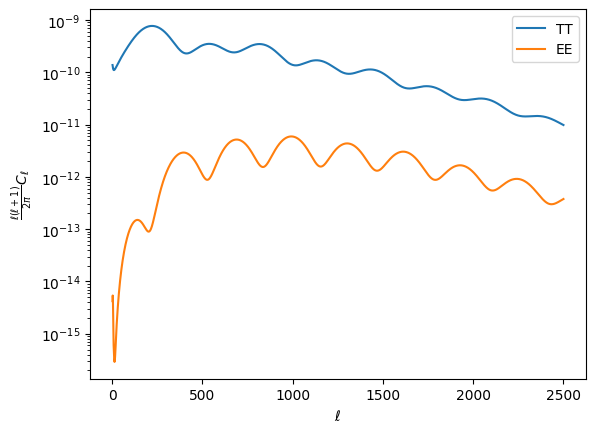

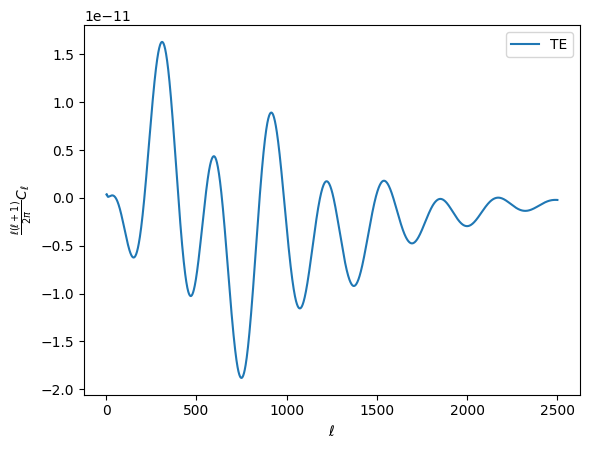

In [10]:
ABC_l = output.l
ABC_tt = output.ClTT * ABC_l * (ABC_l+1)/(2 * jnp.pi)
ABC_te = output.ClTE * ABC_l * (ABC_l+1)/(2 * jnp.pi)
ABC_ee = output.ClEE * ABC_l * (ABC_l+1)/(2 * jnp.pi)

plt.plot(ABC_l, ABC_tt,label="TT")
plt.plot(ABC_l, ABC_ee,label="EE")
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
plt.yscale("log")
plt.legend()
plt.show()

plt.plot(ABC_l, ABC_te,label="TE")
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
#plt.yscale("log")
plt.legend()
plt.show()

There are a number of run options that can be specified at initialization. We note that these are $\textit{not}$ cosmological parameters, but setup parameters related to accuracy, tolerances, input/output etc. All such parameters should be passed in as keyword arguments upon initialization of a `Model` object. For now, let's specify `lmin` and `lmax` (the boundary `l` at which to output power spectra), and also compute the lensed CMB spectrum with `lensing` turned on.

In [11]:
# l_min and l_max define range of output modes l for computation (inclusive)
# lensing = True includes lensing (False by default)
model = Model(l_min=2,l_max=2100, lensing=True)

`model()` sets up background quantities (like $x_e$ and $H$), uses those background quantities to compute the evolution of perturbations, and then finally integrates the resulting transfer function to get $C_{\ell}$s. 

In [12]:
output = model()

The first time you run a new model will take some time due to JAX's JIT compilation. However, any subsequent run on the _same_ `Model` using _different_ params (**not** different specs) will be much faster, since JAX automatically calls the cached compiled code.

We can plot our new result:

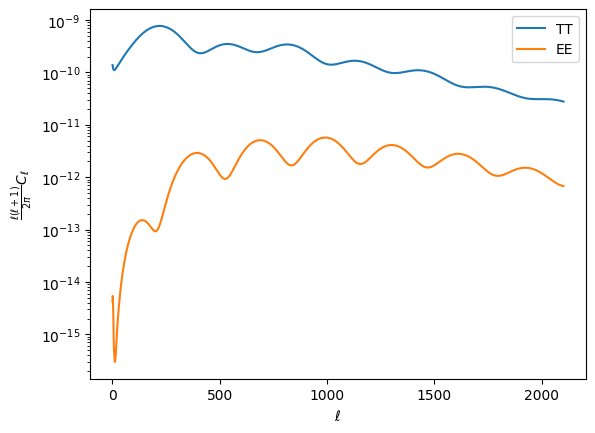

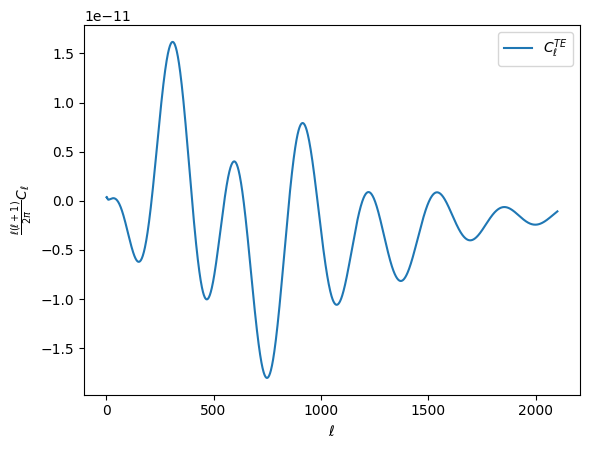

In [13]:
ABC_l = output.l
ABC_tt = output.ClTT * ABC_l * (ABC_l+1)/(2 * jnp.pi)
ABC_te = output.ClTE * ABC_l * (ABC_l+1)/(2 * jnp.pi)
ABC_ee = output.ClEE * ABC_l * (ABC_l+1)/(2 * jnp.pi)

plt.plot(ABC_l, ABC_tt,label='TT')
plt.plot(ABC_l, ABC_ee,label='EE')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
plt.yscale("log")
plt.legend()
plt.show()

plt.plot(ABC_l, ABC_te,label=r'$C_{\ell}^{TE}$')
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\frac{\ell(\ell + 1)}{2\pi} C_{\ell}$')
#plt.yscale("log")
plt.legend()
plt.show()

## Specifying params and run options

`Model` has a number of options that can be specified at initialization.  Attempting to change these options will trigger recompilation when `run_cosmology` is called.  See companion paper for a full list of options.

For example, let's change the `bbn_type` to `Table` to infer `params['YHe']` from `params['omega_b']` and `params['Neff']`. This should be specified in `Model` as a keyword argument.

In [14]:
model2 = Model(bbn_type="Table")

The parameters dictionary can be changed without triggering recompilation, as long as all inputs to the same variable have the same `dtype` and `shape`.

In the function below, we will be running `model2` for a few values of $\omega_b = \Omega_b h^2$, while keeping $\omega_m$ fixed by making up the missing portion with dark matter. Let's take a look at the results and the run time:

In [15]:
def f(omega_b):
    omega_m   = 0.3 * 0.7**2 
    omega_cdm = omega_m - omega_b
    params = {"omega_b" : omega_b, "omega_cdm" : omega_cdm}
    return model2(params)


              /\  
             /  \   
            / /\ \  
           / /__\ \    ___   ___  
          / ______ \  | _ \ / __\ _  _  
         / /      \ \ |  _// /   | \/ | __  
        / /        \ \| _ \\ \___||\/||| -)  
       /_/          \_|___/ \___/||  |||_-) is compiling...
\_____/      

96.02471232414246
6.957783937454224
7.0197553634643555


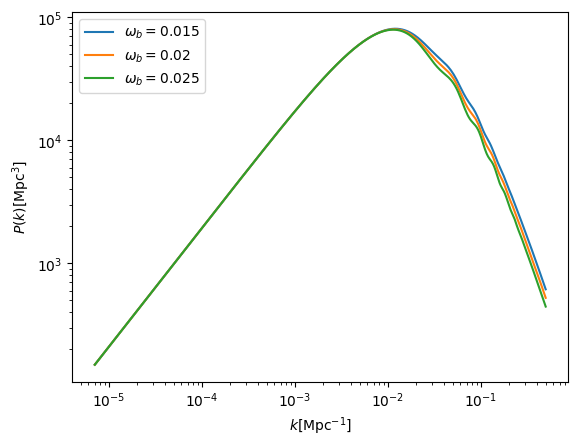

In [16]:
jf = jit(f) # run with the JIT-compiled version of the function

for omega_b in [0.015, 0.02, 0.025]:
    s = time.time()
    output = jf(omega_b)
    output.Pk.block_until_ready() # Avoiding Jax asynchronous dispatch for faithful speedtest.
    print(time.time() - s)

    k  = output.k
    Pk = output.Pk
    plt.loglog(k,Pk, label=r"$\omega_b={}$".format(omega_b))
plt.xlabel(r'$k [{\rm Mpc}^{-1}]$')
plt.ylabel(r'$P(k) [{\rm Mpc}^3]$')
plt.legend()
plt.show()

## Background and Perturbations

ABCMB runs and stores background and perturbation related quantities before using them to compute the output spectra. Of these, the background module contains various energy densities, Hubble, conformal time, as wl as all recombination quantities such as the electron fraction. Perturbations stores a table of metric and fluid perturbations over time and wavenumbers.

Two objects containing these information are returned in `output`:

In [18]:
myModel = Model()
output = myModel()
full_params = output.params # Full list of parameters used
PT          = output.PT # A pertubations table object
BG          = output.BG # A background object

In addition to the objects `PT` and `BG`, a full dictionary of input + derived parameters is always returned in `output.params`. This dictionary is helpful in evaluating some of the background functions in addition to giving a general overview.

Some background quantities can be plotted. Such as Hubble:

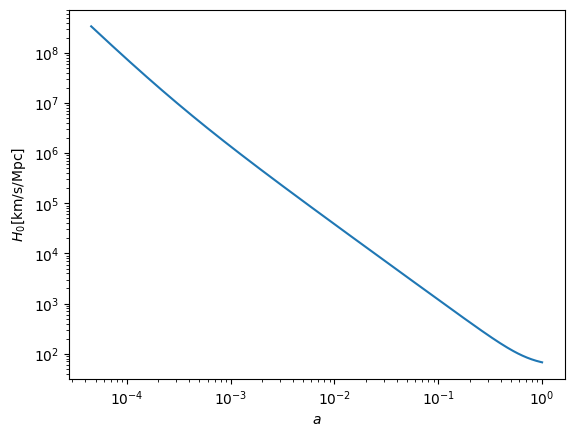

In [19]:
lna = jnp.linspace(-10, 0, 300)
hubble = BG.H(lna, full_params) / 3.24078e-20
plt.loglog(jnp.exp(lna), hubble)
plt.ylabel(r"$H_0 [{\rm km/s/Mpc}]$")
plt.xlabel(r"$a$")
plt.show()

The free electron fraction:

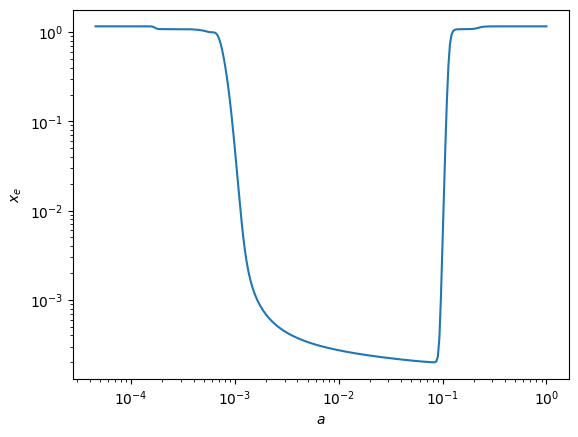

In [20]:
lna = jnp.linspace(-10, 0, 300)
xe = BG.xe(lna)
plt.loglog(jnp.exp(lna), xe)
plt.ylabel(r"$x_e$")
plt.xlabel(r"$a$")
plt.show()

Baryon temperature:

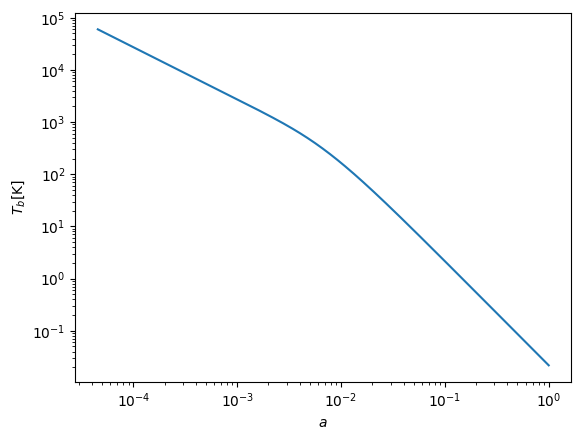

In [21]:
lna = jnp.linspace(-10, 0, 300)
Tm = BG.Tm(lna, full_params) / 8.617e-5 # Convert units to K
plt.loglog(jnp.exp(lna), Tm)
plt.ylabel(r"$T_b [\rm K]$")
plt.xlabel(r"$a$")
plt.show()

Perturbations of cosmological fluids are stored inside a `PerturbationsTable` (PT). The full list of stored quantities are as follows. All quantities are in the synchronous gauge, tabulated 2d arrays over the time axis `lna` and wavenumbers `k`. 

In [36]:
PT

PerturbationTable(
  k=f64[511],
  lna=f64[500],
  delta_m=f64[500,511],
  delta_dm=f64[500,511],
  delta_b=f64[500,511],
  theta_b=f64[500,511],
  theta_b_prime=f64[500,511],
  delta_g=f64[500,511],
  theta_g=f64[500,511],
  sigma_g=f64[500,511],
  Gg0=f64[500,511],
  Gg2=f64[500,511],
  metric_h=f64[500,511],
  metric_eta=f64[500,511],
  metric_h_prime=f64[500,511],
  metric_eta_prime=f64[500,511],
  metric_alpha=f64[500,511],
  metric_alpha_prime=f64[500,511]
)

These can also be plotted. For instance the photon temperature perturbations go as

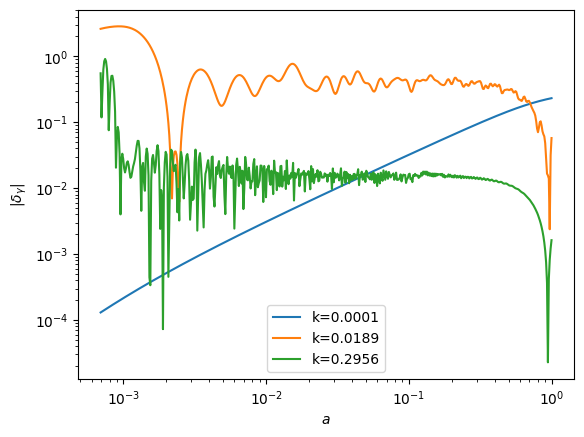

In [22]:
# plot the photon perturbation as a function of redshift for a couple different k's, in 1/Mpc
for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.delta_g[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\delta_\gamma|$')
plt.show()

Baryon density and velocity perturbations for a couple of selected values of $k$:

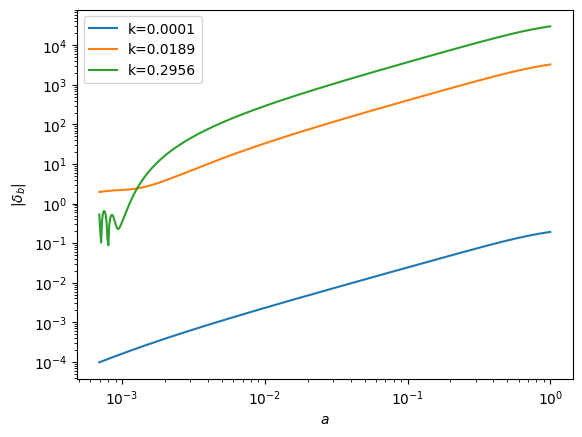

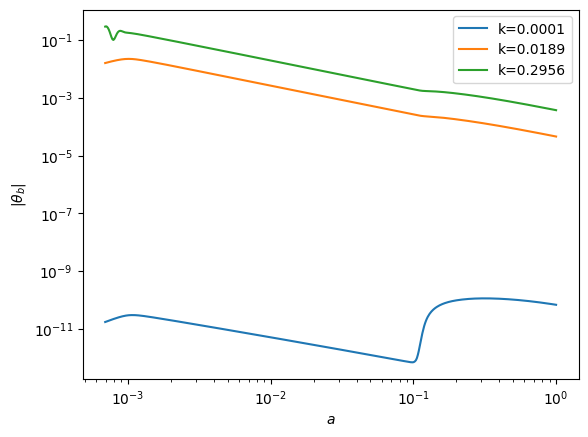

In [23]:
for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.delta_b[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\delta_b|$')
plt.show()

for k_ind in [10,250,500]:
    plt.loglog(jnp.exp(PT.lna), jnp.abs(PT.theta_b[:,k_ind]),label="k={k:.4f}".format(k=PT.k[k_ind]))
plt.legend()
plt.xlabel(r'$a$')
plt.ylabel(r'$|\theta_b|$')
plt.show()